In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
df = pd.read_csv("electricity_cost_dataset.csv")
df.head(5)

,site area,structure type,water consumption,recycling rate,utilisation rate,air qality index,issue reolution time,resident count,electricity cost
0,1360,Mixed-use,2519,69,52,188,1,72,1420
1,4272,Mixed-use,2324,50,76,165,65,261,3298
2,3592,Mixed-use,2701,20,94,198,39,117,3115
3,966,Residential,1000,13,60,74,3,35,1575
4,4926,Residential,5990,23,65,32,57,185,4301


In [29]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 9321 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   site area                   9321 non-null   int64
 1   water consumption           9321 non-null   int64
 2   recycling rate              9321 non-null   int64
 3   utilisation rate            9321 non-null   int64
 4   air qality index            9321 non-null   int64
 5   issue reolution time        9321 non-null   int64
 6   resident count              9321 non-null   int64
 7   electricity cost            9321 non-null   int64
 8   structure type_Industrial   9321 non-null   bool 
 9   structure type_Mixed-use    9321 non-null   bool 
 10  structure type_Residential  9321 non-null   bool 
dtypes: bool(3), int64(8)
memory usage: 682.7 KB
None


In [30]:
df.dtypes

site area                     int64
water consumption             int64
recycling rate                int64
utilisation rate              int64
air qality index              int64
issue reolution time          int64
resident count                int64
electricity cost              int64
structure type_Industrial      bool
structure type_Mixed-use       bool
structure type_Residential     bool
dtype: object

In [4]:
print(df.describe())

          site area  water consumption  recycling rate  utilisation rate  \
count  10000.000000       10000.000000    10000.000000      10000.000000   
mean    2757.775100        3494.057100       49.598000         64.842200   
std     1293.059959        2076.181117       23.430141         20.432965   
min      501.000000        1000.000000       10.000000         30.000000   
25%     1624.000000        1779.000000       29.750000         47.000000   
50%     2773.500000        3047.500000       49.000000         65.000000   
75%     3874.000000        4811.000000       70.000000         83.000000   
max     5000.000000       10894.000000       90.000000        100.000000   

       air qality index  issue reolution time  resident count  \
count      10000.000000          10000.000000    10000.000000   
mean          99.468600             36.402600       85.573100   
std           58.014526             20.623905      107.876179   
min            0.000000              1.000000        0.

In [4]:
df.isnull().sum()

site area               0
structure type          0
water consumption       0
recycling rate          0
utilisation rate        0
air qality index        0
issue reolution time    0
resident count          0
electricity cost        0
dtype: int64

In [6]:

num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [8]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

df = df.drop_duplicates()
print("After removing:", df.duplicated().sum())

Duplicate rows: 0
After removing: 0


In [11]:
print("Before removing outliers:", df.shape)

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("After removing outliers:", df.shape)

Before removing outliers: (9462, 9)
After removing outliers: (9321, 9)


In [18]:
df = pd.get_dummies(df, columns=["structure type"], drop_first=True)
print("After Encoding")
print(df.head())


After Encoding
   site area  water consumption  recycling rate  utilisation rate  \
0       1360               2519              69                52   
1       4272               2324              50                76   
2       3592               2701              20                94   
3        966               1000              13                60   
4       4926               5990              23                65   

   air qality index  issue reolution time  resident count  electricity cost  \
0               188                     1              72              1420   
1               165                    65             261              3298   
2               198                    39             117              3115   
3                74                     3              35              1575   
4                32                    57             185              4301   

   structure type_Industrial  structure type_Mixed-use  \
0                      False         

In [19]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()    

Duplicates: 0


In [56]:
x = df.drop("electricity cost", axis=1)
y = df["electricity cost"]

y

0       1420
1       3298
2       3115
3       1575
4       4301
        ... 
9995     885
9996    3081
9997    3325
9998    2892
9999    2603
Name: electricity cost, Length: 9321, dtype: int64

In [21]:
scaler = StandardScaler()
x = scaler.fit_transform(x)
x

array([[-1.02000812, -0.41107717,  0.82950441, ..., -0.34511148,
         2.0232258 , -0.78003562],
       [ 1.29847421, -0.51125844,  0.01880951, ..., -0.34511148,
         2.0232258 , -0.78003562],
       [ 0.75707037, -0.31757466, -1.26123507, ..., -0.34511148,
         2.0232258 , -0.78003562],
       ...,
       [ 1.03573411, -0.45834218,  0.48815919, ..., -0.34511148,
        -0.49426021, -0.78003562],
       [ 0.45372498,  0.67807299,  0.95750887, ..., -0.34511148,
        -0.49426021, -0.78003562],
       [ 0.15595287, -0.10025837,  0.01880951, ..., -0.34511148,
        -0.49426021, -0.78003562]], shape=(9321, 10))

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x , y, test_size=0.2, random_state=42)
print("Train Shape:", x_train.shape)
print("Test Shape:", x_test.shape)
x_train,y_train

Train Shape: (7456, 10)
Test Shape: (1865, 10)


(array([[ 0.62331177,  0.20336792,  0.57349549, ...,  2.89761442,
         -0.49426021, -0.78003562],
        [-0.54150267, -0.9202035 ,  1.42685854, ..., -0.34511148,
         -0.49426021, -0.78003562],
        [ 0.72203835,  0.87483927, -1.47457583, ..., -0.34511148,
         -0.49426021, -0.78003562],
        ...,
        [-1.50886395, -1.11029103,  0.14681397, ..., -0.34511148,
          2.0232258 , -0.78003562],
        [ 0.27139927,  0.57224048, -0.66388093, ..., -0.34511148,
         -0.49426021, -0.78003562],
        [ 0.40754642,  0.46332546, -1.21856691, ..., -0.34511148,
         -0.49426021,  1.28199274]], shape=(7456, 10)),
 9277    4260
 8421    2248
 7809    3687
 9905    2377
 4577    3828
         ... 
 6157    4082
 5574    4242
 5783     870
 927     3156
 7812    3165
 Name: electricity cost, Length: 7456, dtype: int64)

In [23]:
lr = LinearRegression()
lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [72]:
y_pred_lr = lr.predict(x_test)
y_pred

array([2035.91, 1637.65, 3055.3 , ..., 2757.96, 3534.31, 3614.64],
      shape=(1865,))

In [80]:
print("\nLinear Regression Results")
lr_acc =  r2_score(y_test, y_pred_lr)
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", lr_acc)


Linear Regression Results
MAE: 222.62065369360232
MSE: 78466.92985436079
R2 Score: 0.9266745057760998


In [33]:
train_score = lr.score(x_train, y_train)
test_score = lr.score(x_test, y_test)

print("Train Score:", train_score)
print("Test Score:", test_score)

Train Score: 0.9258553127411581
Test Score: 0.9266745057760998


In [34]:
new_data = pd.DataFrame({

"site area":[2100],
"water consumption":[2000],
"recycling rate":[69],
"utilisation rate":[72],
"air qality index":[190],
"issue reolution time":[1],
"resident count":[80],

"structure type_Industrial":[0],
"structure type_Mixed-use":[1],
"structure type_Residential":[0]

})

In [35]:
new_data_scaled = scaler.transform(new_data)
prediction = lr.predict(new_data_scaled)
print("Predicted Electricity Cost:", prediction[0])

Predicted Electricity Cost: 1746.3072778907563


In [36]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(x_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [77]:
y_pred_dt = dt.predict(x_test)
y_pred

array([2035.91, 1637.65, 3055.3 , ..., 2757.96, 3534.31, 3614.64],
      shape=(1865,))

In [79]:
print("\nDecision Tree Regression Results")
dt_acc =  r2_score(y_test, y_pred_dt)
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("MSE:", mean_squared_error(y_test, y_pred_dt))
print("R2 Score:", dt_acc)


Decision Tree Regression Results
MAE: 250.83002680965149
MSE: 97411.93672922252
R2 Score: 0.908970843930877


In [41]:
train_score = dt.score(x_train, y_train)
test_score = dt.score(x_test, y_test)

print("Train Score:", train_score)
print("Test Score:", test_score)

Train Score: 1.0
Test Score: 0.908970843930877


In [42]:
new_data = pd.DataFrame({

"site area":[2100],
"water consumption":[2000],
"recycling rate":[69],
"utilisation rate":[72],
"air qality index":[190],
"issue reolution time":[1],
"resident count":[80],

"structure type_Industrial":[0],
"structure type_Mixed-use":[1],
"structure type_Residential":[0]

})

In [44]:
new_data_scaled = scaler.transform(new_data)
prediction = dt.predict(new_data_scaled)
print("Predicted Electricity Cost:", prediction[0])

Predicted Electricity Cost: 2032.0


In [47]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [81]:
y_pred_rf = rf.predict(x_test)
y_pred

array([2035.91, 1637.65, 3055.3 , ..., 2757.96, 3534.31, 3614.64],
      shape=(1865,))

In [83]:
print("\nRandom Tree Regression Results")
rf_acc =  r2_score(y_test, y_pred_rf)
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", rf_acc)


Random Tree Regression Results
MAE: 176.32405898123324
MSE: 48914.28477849866
R2 Score: 0.9542907551926771


In [50]:
train_score = rf.score(x_train, y_train)
test_score = rf.score(x_test, y_test)

print("Train Score:", train_score)
print("Test Score:", test_score) # underfiting and overfiting code

Train Score: 0.9935344282050743
Test Score: 0.9542907551926771


In [51]:
new_data = pd.DataFrame({

"site area":[2100],
"water consumption":[2000],
"recycling rate":[69],
"utilisation rate":[72],
"air qality index":[190],
"issue reolution time":[1],
"resident count":[80],

"structure type_Industrial":[0],
"structure type_Mixed-use":[1],
"structure type_Residential":[0]

})

In [53]:
new_data_scaled = scaler.transform(new_data)
prediction = rf.predict(new_data_scaled)
print("Predicted Electricity Cost:", prediction[0]) #predict new data

Predicted Electricity Cost: 1909.92


In [20]:
print("\nBias Variance Check")
print("Linear Regression Train Score:", lr.score(x_train, y_train))
print("Linear Regression Test Score:", lr.score(x_test, y_test))

print("\nDecision Tree Train Score:", dt.score(x_train, y_train))
print("Decision Tree Test Score:", dt.score(x_test, y_test))

print("\nRandom Forest Train Score:", rf.score(x_train, y_train))
print("Random Forest Test Score:", rf.score(x_test, y_test))



Bias Variance Check
Linear Regression Train Score: 0.9224799084910268
Linear Regression Test Score: 0.9219379221210353

Decision Tree Train Score: 1.0
Decision Tree Test Score: 0.9212763777900436

Random Forest Train Score: 0.9942996069458413
Random Forest Test Score: 0.9609398146492775


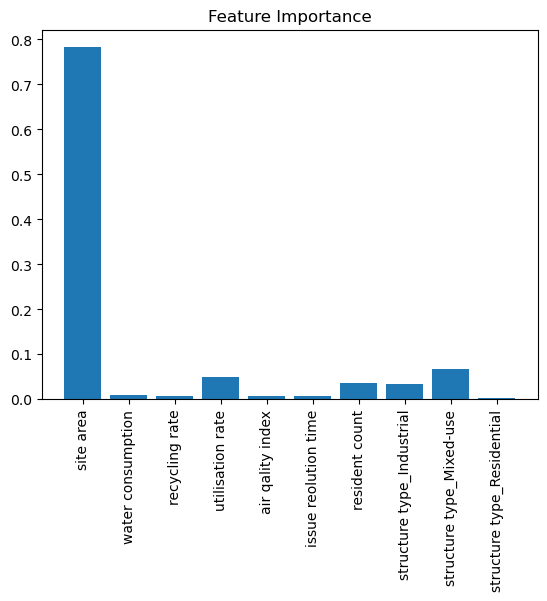

In [58]:
importance = rf.feature_importances_
features = x.columns

plt.figure()
plt.bar(features, importance)
plt.xticks(rotation=90)
plt.title("Feature Importance")
plt.show()


In [59]:
sample = x.iloc[[0]]
sample_data = scaler.transform(sample)
prediction = rf.predict(sample_data)
print("\nPredicted Electricity Cost:", prediction[0])
#predict sample data


Predicted Electricity Cost: 1447.65


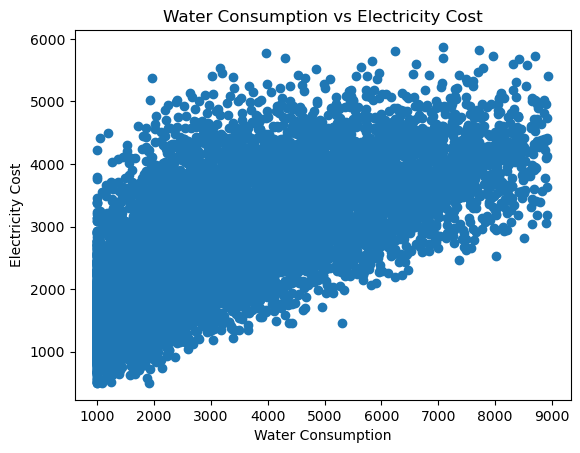

In [60]:
plt.figure()
plt.scatter(df["water consumption"], df["electricity cost"])
plt.xlabel("Water Consumption")
plt.ylabel("Electricity Cost")
plt.title("Water Consumption vs Electricity Cost")
plt.show()
# water consumption Vs electricity cost

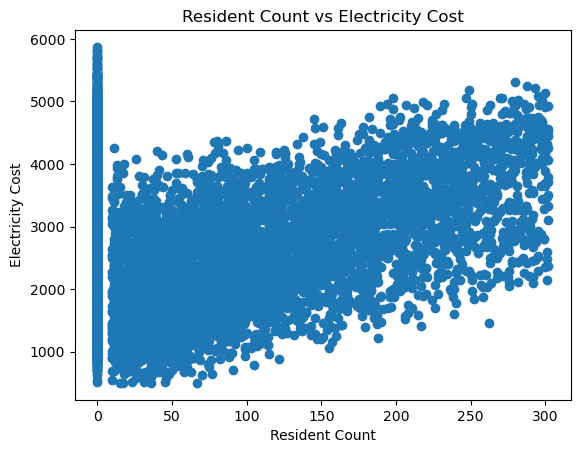

In [61]:
plt.figure()
plt.scatter(df["resident count"], df["electricity cost"])
plt.xlabel("Resident Count")
plt.ylabel("Electricity Cost")
plt.title("Resident Count vs Electricity Cost")
plt.show()


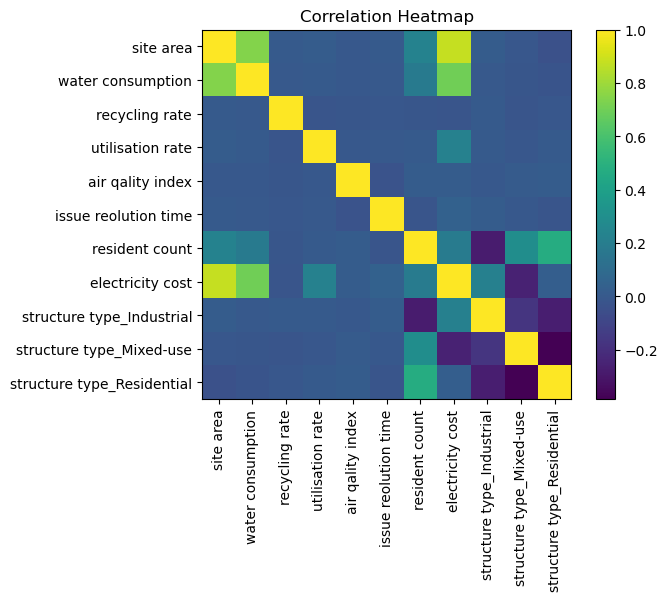

In [62]:
corr = df.corr()
plt.figure()
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.colorbar()
plt.show()


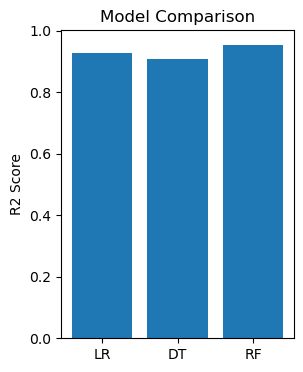

In [88]:
models = ["LR", "DT", "RF"]
scores = [ lr_acc,dt_acc,rf_acc ]
plt.figure(figsize=(3,4))
plt.bar(models, scores)
plt.ylabel("R2 Score")
plt.title("Model Comparison")
plt.show()


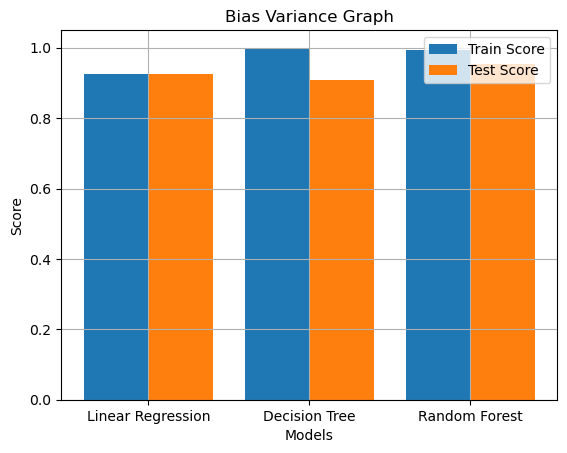

In [89]:
train_scores = [
    lr.score(x_train, y_train),
    dt.score(x_train, y_train),
    rf.score(x_train, y_train)
]
test_scores = [
    lr.score(x_test, y_test),
    dt.score(x_test, y_test),
    rf.score(x_test, y_test)
]
models = ["Linear Regression","Decision Tree","Random Forest"]
x = np.arange(len(models))
plt.figure()
plt.bar(x - 0.2, train_scores, width=0.4,label="Train Score")
plt.bar(x + 0.2, test_scores, width=0.4,label="Test Score")
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks(x, models)
plt.title("Bias Variance Graph")
plt.legend()
plt.grid()
plt.show()


In [101]:
param_grid = {
    "fit_intercept": [True, False],
    "positive": [True, False]
}

In [102]:
grid = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)
grid.fit(x_train,y_train)

,estimator,LinearRegression()
,param_grid,"{'fit_intercept': [True, False], 'positive': [True, False]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,fit_intercept,True


In [103]:
print("Linear Regression GridSearch")
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)


Linear Regression GridSearch
Best Parameters: {'fit_intercept': True, 'positive': False}
Best Score: 0.9254823892069114


In [104]:
param_grid = {
    "max_depth": [5,10,15,20],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}


In [94]:
grid = GridSearchCV(
    estimator=DecisionTreeRegressor(),
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)
grid.fit(x_train,y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [106]:
print("Decision Tree Regression GridSearch")
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)


Decision Tree Regression GridSearch
Best Parameters: {'fit_intercept': True, 'positive': False}
Best Score: 0.9254823892069114


In [ ]:
# param_grid_rf = {
#     'n_estimators': [50, 100],
#     'max_depth': [5, 10, None],
#     'min_samples_split': [2, 5],
#     'min_samples_leaf': [1, 2]
# }

In [ ]:
# grid_rf = GridSearchCV(
#     estimator=rf,
#     param_grid=param_grid_rf,
#     cv=5,
#     scoring='r2',
#     n_jobs=-1
# )

In [ ]:
# print("Best Parameters:", grid.best_params_)
# print("Best Score:", grid.best_score_)


In [107]:
param_dist_lr = {
    "fit_intercept": [True, False],
    "positive": [True, False]
}


In [109]:
random_lr = RandomizedSearchCV(
    estimator=lr,
    param_distributions=param_dist_lr,
    n_iter=4,
    cv=5,
    scoring="r2",
    random_state=42
)
random_lr.fit(x_train, y_train)


,estimator,LinearRegression()
,param_distributions,"{'fit_intercept': [True, False], 'positive': [True, False]}"
,n_iter,4
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [110]:
print("\nLinear Regression RandomizedSearch")
print("Best Parameters:", random_lr.best_params_)
print("Best Score:", random_lr.best_score_)



Linear Regression RandomizedSearch
Best Parameters: {'positive': False, 'fit_intercept': True}
Best Score: 0.9254823892069114


In [112]:
param_dist_dt = {
    "max_depth": np.arange(3,20),
    "min_samples_split": np.arange(2,10),
    "min_samples_leaf": np.arange(1,5)
}

In [113]:
random_dt = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist_dt,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42
)
random_dt.fit(x_train,y_train)

,estimator,DecisionTreeR...ndom_state=42)
,param_distributions,"{'max_depth': array([ 3, 4..., 17, 18, 19]), 'min_samples_leaf': array([1, 2, 3, 4]), 'min_samples_split': array([2, 3, ..., 6, 7, 8, 9])}"
,n_iter,20
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [114]:
print("\nDecision Tree RandomizedSearch")
print("Best Parameters:", random_dt.best_params_)
print("Best Score:", random_dt.best_score_)



Decision Tree RandomizedSearch
Best Parameters: {'min_samples_split': np.int64(8), 'min_samples_leaf': np.int64(4), 'max_depth': np.int64(14)}
Best Score: 0.9251381864249566


In [ ]:
# param_dist_rf = {
#     "n_estimators": np.arange(50,300,50),
#     "max_depth": np.arange(5,30),
#     "min_samples_split": np.arange(2,10),
#     "min_samples_leaf": np.arange(1,5)
# }


In [ ]:
# random_rf = RandomizedSearchCV(
#     estimator=rf,
#     param_distributions=param_dist_rf,
#     n_iter=20,
#     cv=5,
#     scoring="r2",
#     random_state=42
# )
# random_rf.fit(x_train,y_train)

In [ ]:
# print("\nRandom Forest RandomizedSearch")
# print("Best Parameters:", random_rf.best_params_)
# print("Best Score:", random_rf.best_score_

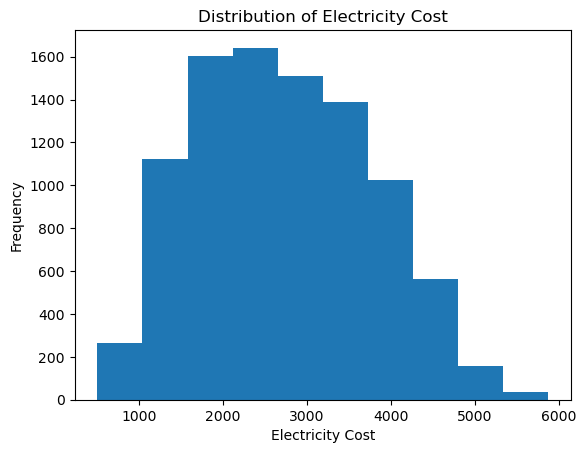

In [115]:
plt.figure()
plt.hist(df["electricity cost"])
plt.xlabel("Electricity Cost")
plt.ylabel("Frequency")
plt.title("Distribution of Electricity Cost")
plt.show()


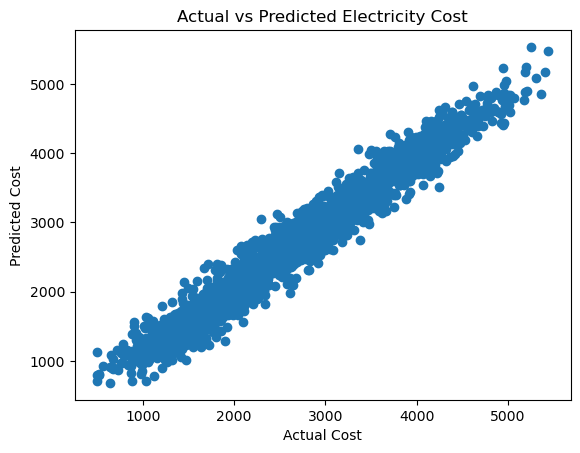

In [116]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Cost")
plt.ylabel("Predicted Cost")
plt.title("Actual vs Predicted Electricity Cost")
plt.show()


In [118]:
# Add this to your notebook after training the model
import pickle

# Save the model and scaler
pickle.dump(rf, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
